<center><h1> Predicción del precio de acciones Nvidia.</h1><br>

### Akira Cruz Marentes
### 31 de diciembre de 2025
</center>

## 1. Introducción

En este notebook se estudiará la serie de tiempo del valor de las acciones de la empresa tecnológica Nvidia, la cual ha tomado más importancia en los últimos años debido a la avance de la inteligencia artificial.

Se emplearan diversos modelos de predicción y se medirá el desempeño de cada uno.

## 2. Objetivos

### Objetivo principal

Construir un modelo que prediga el valor de cierre de las acciones de Nvidia

### Objetivo secundario
Relacionarse con el uso de librerías prophet, pmdarima y yfinance


## 3. Descripción del Dataset

Este dataset es una serie de tiempo que describe los valores del stock de Nvidia, extraído de yahoo finance utilizando la librería yfinance.

El dataset contiene 6 columnas y el indice se extiende hasta 1999

### Variables relevantes para el análisis:
- Open: Precio inicial.
- High: Precio máximo en el transcurso del día.
- Low: Precio mínimo en el transcurso del día.
- Close (objetivo): Precio final (cierre).
- Volume: Cantidad total de acciones de la empresa.


## 4. Exploración de Datos (EDA)

In [1]:
# Cargamos las librerías a utilizar

import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd 
import yfinance as yf
import seaborn as sns
import pmdarima as pm
from prophet import Prophet


c:\Users\Akira\Documents\Colab Notebooks\tsa\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Carga del objeto de yfinance del dataset de Nvidia.

ticker = yf.Ticker("NVDA")

# Cargamos los datos históricos con antigüedad máxima de 2 años.
historical_data = ticker.history(period="2y") 

# Información del dataset

print("Historical Data:")
print(historical_data.head())

print("\n Información del dataset:")
print(historical_data.info())

print("\n Estadísticas descriptivas:")
print(historical_data.describe())

print("\n Total de filas duplicadas:")
print(historical_data.duplicated().sum())

print("\n Total de valores faltantes por columna:")
print(historical_data.isnull().sum())

Historical Data:
                                Open       High        Low      Close  \
Date                                                                    
2024-01-02 00:00:00-05:00  49.216575  49.267546  47.568495  48.141174   
2024-01-03 00:00:00-05:00  47.458558  48.157166  47.293649  47.542511   
2024-01-04 00:00:00-05:00  47.740401  48.472995  47.481546  47.971275   
2024-01-05 00:00:00-05:00  48.435015  49.519410  48.279100  49.069660   
2024-01-08 00:00:00-05:00  49.484433  52.245895  49.451450  52.223904   

                              Volume  Dividends  Stock Splits  
Date                                                           
2024-01-02 00:00:00-05:00  411254000        0.0           0.0  
2024-01-03 00:00:00-05:00  320896000        0.0           0.0  
2024-01-04 00:00:00-05:00  306535000        0.0           0.0  
2024-01-05 00:00:00-05:00  415039000        0.0           0.0  
2024-01-08 00:00:00-05:00  642510000        0.0           0.0  

 Información del datas

In [3]:
# Modificamos el índice para que aparezca solo la fecha 
historical_data.reset_index(inplace = True)
historical_data["Date"] = historical_data["Date"].dt.date 
historical_data.set_index("Date", inplace=True)    

# Quitamos las variables que no utilizaremos.
historical_data.drop(["Stock Splits", "Dividends"], axis = 1, inplace = True)
historical_data

,Open,High,Low,Close,Volume
Date,,,,,
2024-01-02,49.216575,49.267546,47.568495,48.141174,411254000
2024-01-03,47.458558,48.157166,47.293649,47.542511,320896000
2024-01-04,47.740401,48.472995,47.481546,47.971275,306535000
2024-01-05,48.435015,49.519410,48.279100,49.069660,415039000
2024-01-08,49.484433,52.245895,49.451450,52.223904,642510000
...,...,...,...,...,...
2025-12-24,187.940002,188.910004,186.589996,188.610001,65528500
2025-12-26,189.919998,192.690002,188.000000,190.529999,139740300
2025-12-29,187.710007,188.759995,185.910004,188.220001,120006100


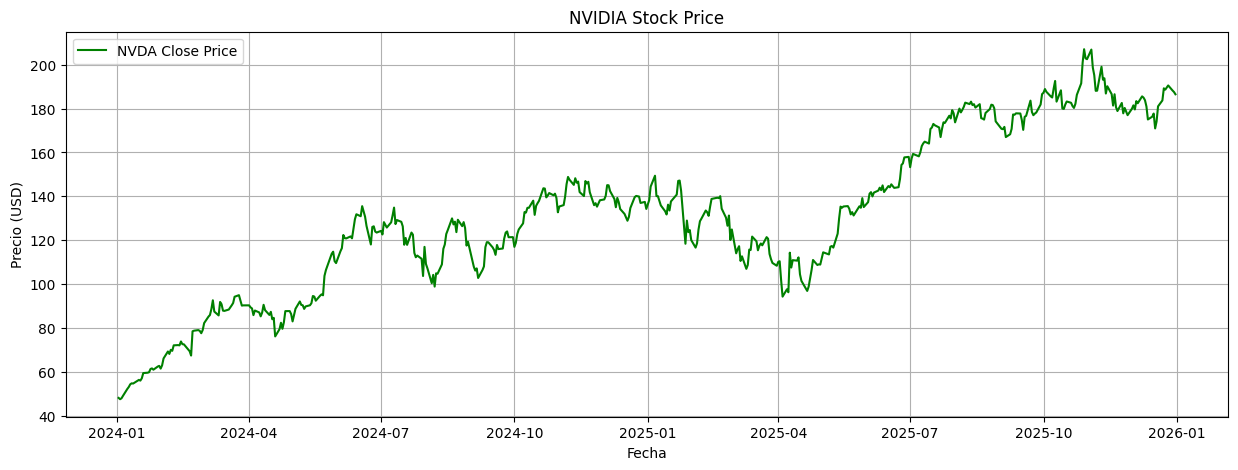

In [4]:
# Graficamos la variable objetivo.

plt.figure(figsize=(15,5))
plt.plot(historical_data["Close"], label = "NVDA Close Price", color ="green")
plt.title("NVIDIA Stock Price")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD)")
plt.legend()
plt.grid()
plt.show()

No se encontraron datos faltantes ni datos duplicados, por lo que no se necesitó de limparlos.

Por el índole de los datos, no es necesario identificar outliers u otro estudio estadístico.

## 5. Modelo predictivo

Utilizaremos varios modelos, donde evaluaremos el desempeño en la predicción y rapidez de su ejecución.

Para evaluar los modelos, utilizaremos los últimos 30 días como datos de prueba

### Red Neuronal (LSTM)

Utilizaremos una red neuronal del tipo Long-Short Term Memory (LSTM), el cual es ampliamente usada en el análisis de series temporales debido a su capacidad de captar solo los patrones relevantes y captar relaciones no lineales.

In [51]:
# Separación de datos de entrenamiento y prueba
# En esta sección se hace así ya que después utilizaremos una ventana deslizante.

days = 30
n = int(len(historical_data))- 5
split = int(n-days)
training_len = split + 5

train_data = historical_data.iloc[:training_len]
test_data = historical_data.iloc[training_len:]

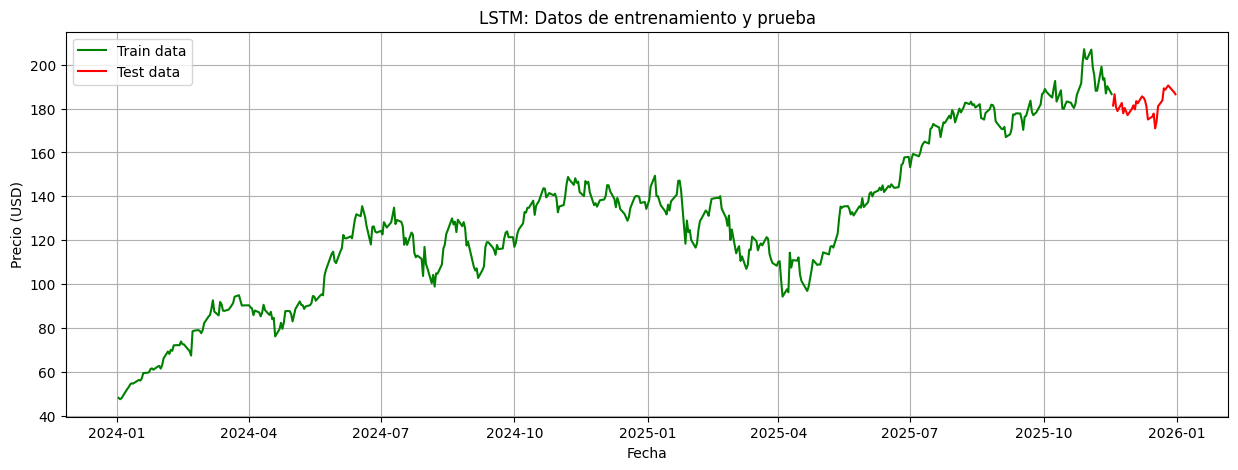

In [52]:
# Gráfica de los datos de entrenamiento y prueba

plt.figure(figsize=(15,5))
plt.plot(historical_data.index[:training_len], train_data["Close"], color = "g", label = "Train data")
plt.plot(historical_data.index[training_len:], test_data["Close"], color = "r", label = "Test data")
plt.grid()
plt.legend()
plt.title("LSTM: Datos de entrenamiento y prueba")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD)")
plt.show()

In [53]:
# Preparación de los datos 

from sklearn.preprocessing import StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X = historical_data.drop(["Close"], axis=1).values
y = historical_data['Close'].values.reshape(-1,1)

X_s = scaler_X.fit_transform(X)
y_s = scaler_y.fit_transform(y)

# Función de ventana temporal

def create_sequences(X, y, seq_len=10):
    Xs, ys = [], []
    for i in range(len(X)-seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

# Ventana temporal de 5 días
seq_len = 5
X_seq, y_seq = create_sequences(X_s, y_s, seq_len)

# División train/test (walk-forward es preferible)
split = int(len(X_seq)-days)
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

In [64]:
from tensorflow import keras

# Creación del modelo

model = keras.Sequential([
    keras.layers.LSTM(64, return_sequences=False, input_shape=(seq_len, X.shape[1])),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1)
])
model.compile(optimizer='adam', loss='mae')

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4)
]
history = model.fit(X_train, y_train, validation_split=0.1, epochs=20, batch_size=32, callbacks=callbacks)

model.summary()

# Predecir e inversa
y_pred_s = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_s)
y_true = scaler_y.inverse_transform(y_test)

Epoch 1/20


c:\Users\Akira\Documents\Colab Notebooks\tsa\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.4046 - val_loss: 0.2567 - learning_rate: 0.0010
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2090 - val_loss: 0.3519 - learning_rate: 0.0010
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1868 - val_loss: 0.1617 - learning_rate: 0.0010
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1697 - val_loss: 0.1344 - learning_rate: 0.0010
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1601 - val_loss: 0.1545 - learning_rate: 0.0010
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1619 - val_loss: 0.1243 - learning_rate: 0.0010
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1525 - val_loss: 0.1230 - learning_rate: 0.0010
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1447 - val_loss: 0.1363 - learning_rate: 0.0010
Epoch 9/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1532 - val_loss: 0.1430 - learning_rate: 0.0010
Epoch 10/20
14/14 ━━━━━━━━━━━━

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_15 (LSTM)                  │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,341 (306.02 KB)

 Trainable params: 26,113 (102.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 52,228 (204.02 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step


### ARIMA

Utilizaremos el modelo ARIMA como el estándar de comparación, ya que es un modelo básico en el análisis de series temporales.

Para la implementación, usaremos la función AutoArima de la librería pmdarima, la cual calcula los mejores hiperparámetros según los datos.

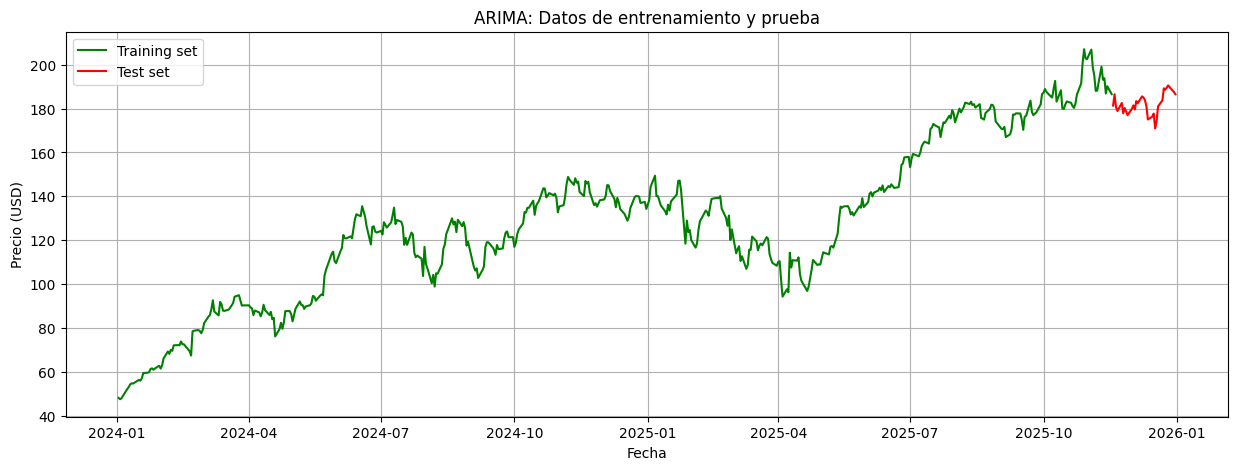

In [9]:
from pmdarima.model_selection import train_test_split

# División de datos de entrenamiento y prueba

train, test = train_test_split(historical_data["Close"].values, test_size=30)

plt.figure(figsize=(15,5))
plt.plot(historical_data.index[:training_len], train, label="Training set", color="g")
plt.plot(historical_data.index[training_len:], test, label="Test set", color="r")
plt.grid()
plt.legend()
plt.title("ARIMA: Datos de entrenamiento y prueba")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD)")
plt.show()

In [32]:
from pmdarima.pipeline import Pipeline
from pmdarima.preprocessing import BoxCoxEndogTransformer



pipeline = Pipeline([
    ('boxcox', BoxCoxEndogTransformer()),        # Preparación de datos
    ('arima', pm.AutoARIMA(seasonal=True, m=5,  # Modelo
                           stepwise=True,
                           suppress_warnings=True,
                           trace=True,
                           approximation=True,
                           information_criterion="aic",
                           error_action="ignore"))
])

pipeline.fit(train)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[5] intercept   : AIC=2113.218, Time=2.57 sec
 ARIMA(0,1,0)(0,0,0)[5] intercept   : AIC=2114.366, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[5] intercept   : AIC=2111.611, Time=0.21 sec
 ARIMA(0,1,1)(0,0,1)[5] intercept   : AIC=2112.225, Time=0.19 sec
 ARIMA(0,1,0)(0,0,0)[5]             : AIC=2115.083, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[5] intercept   : AIC=2111.345, Time=0.08 sec
 ARIMA(1,1,0)(0,0,1)[5] intercept   : AIC=2111.463, Time=0.16 sec
 ARIMA(1,1,0)(1,0,1)[5] intercept   : AIC=2113.217, Time=0.58 sec
 ARIMA(2,1,0)(0,0,0)[5] intercept   : AIC=2108.387, Time=0.11 sec
 ARIMA(2,1,0)(1,0,0)[5] intercept   : AIC=2109.391, Time=0.23 sec
 ARIMA(2,1,0)(0,0,1)[5] intercept   : AIC=2109.290, Time=0.21 sec
 ARIMA(2,1,0)(1,0,1)[5] intercept   : AIC=2110.988, Time=0.75 sec
 ARIMA(3,1,0)(0,0,0)[5] intercept   : AIC=2106.014, Time=0.15 sec
 ARIMA(3,1,0)(1,0,0)[5] intercept   : AIC=2107.408, Time=0.29 sec
 ARIMA(3,1,0)(0,0,1)[5] intercept

,steps,"[('boxcox', ...), ('arima', ...)]"


In [33]:
# Predicción
n_periods = int(len(test))
preds, conf_int = pipeline.predict(n_periods=n_periods, return_conf_int=True)



c:\Users\Akira\Documents\Colab Notebooks\tsa\.venv\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['approximation']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


### Prophet

Prophet es un modelo de predicción creado por el equipo de ciencia de datos de Facebook.

In [12]:
# Preparación de datos 

prophet_data = historical_data.reset_index()
prophet_data.rename(columns={"Date" : "ds", "Close" : "y"}, inplace=True)

prophet_data

,ds,Open,High,Low,y,Volume
0,2024-01-02,49.216575,49.267546,47.568495,48.141174,411254000
1,2024-01-03,47.458558,48.157166,47.293649,47.542511,320896000
2,2024-01-04,47.740401,48.472995,47.481546,47.971275,306535000
3,2024-01-05,48.435015,49.519410,48.279100,49.069660,415039000
4,2024-01-08,49.484433,52.245895,49.451450,52.223904,642510000
...,...,...,...,...,...,...
497,2025-12-24,187.940002,188.910004,186.589996,188.610001,65528500
498,2025-12-26,189.919998,192.690002,188.000000,190.529999,139740300
499,2025-12-29,187.710007,188.759995,185.910004,188.220001,120006100
500,2025-12-30,188.240005,188.990005,186.929993,187.539993,97687300


Última fecha del training set:
2025-11-17
Primera fecha del test set: 
2025-11-18


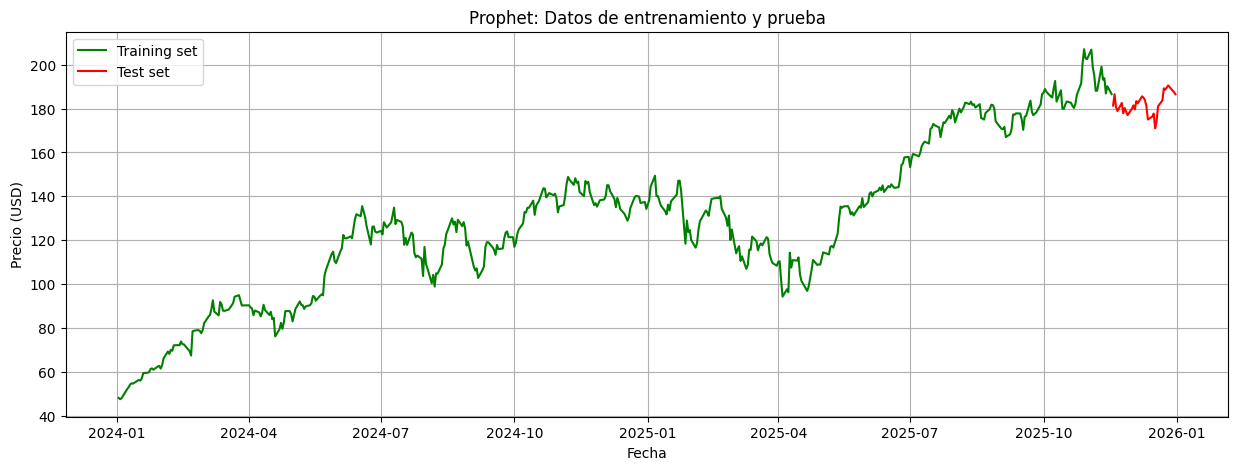

In [13]:
# Separación de datos

prophet_test = prophet_data.iloc[-30:]
prophet_train = prophet_data.iloc[:-30]

print(f"Última fecha del training set:\n{prophet_train["ds"].iloc[-1]}")
print(f"Primera fecha del test set: \n{prophet_test["ds"].iloc[0]}")

plt.figure(figsize=(15,5))
plt.plot(prophet_train["ds"], prophet_train["y"], label="Training set", color="g")
plt.plot(prophet_test["ds"], prophet_test["y"], label="Test set", color="r")
plt.grid()
plt.legend()
plt.title("Prophet: Datos de entrenamiento y prueba")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD)")
plt.show()

In [14]:
# Construcción del modelo

Regressors = ["Open", "High", "Low"]


model_prophet= Prophet(yearly_seasonality=True,
                        weekly_seasonality=True,
                        daily_seasonality=False)
for reg in Regressors:
    model_prophet.add_regressor(reg)

model_prophet.fit(prophet_train[["ds","y"] + Regressors])

17:38:02 - cmdstanpy - INFO - Chain [1] start processing
17:38:03 - cmdstanpy - INFO - Chain [1] done processing


In [15]:
# Predicción
Forecast_Prophet = model_prophet.predict(prophet_test[["ds"] + Regressors])

Componentes de periodicidad:



C:\Users\Akira\AppData\Local\Temp\ipykernel_28436\226336293.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  Prophet_components.show()


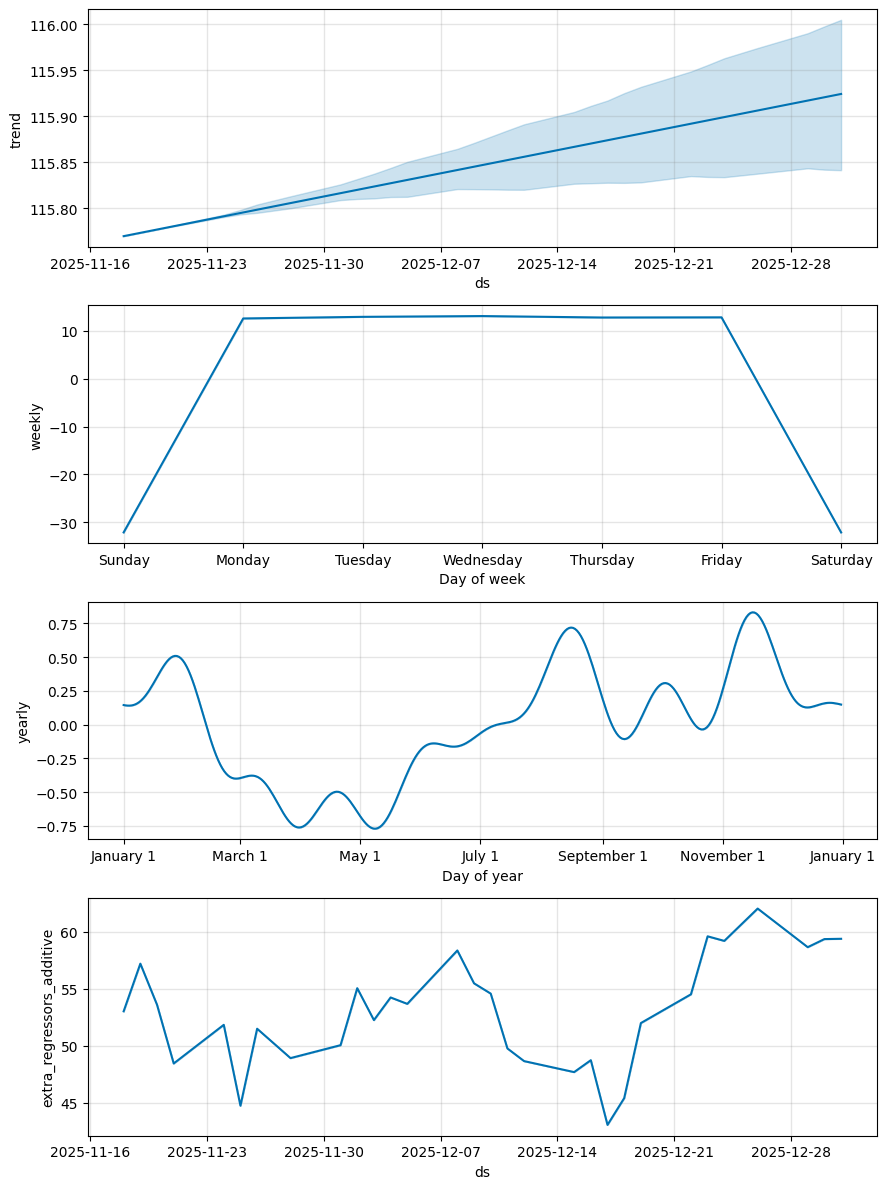

In [16]:
print("Componentes de periodicidad:\n")
Prophet_components = model_prophet.plot_components(Forecast_Prophet)
Prophet_components.show()

In [17]:
# Verificación de la cantidad de predicciónes
Prophet_predictions = Forecast_Prophet["yhat"].values
Prophet_predictions.shape

(30,)

## 6. Evaluación de Modelos

Red Neuronal:
MAE = 3.65, RMSE = 4.56

ARIMA:
MAE = 11.44, RMSE = 12.36

Prophet:
MAE = 1.07, RMSE = 1.42



C:\Users\Akira\AppData\Local\Temp\ipykernel_28436\1827318164.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data["Predictions"] = y_pred_n


[]

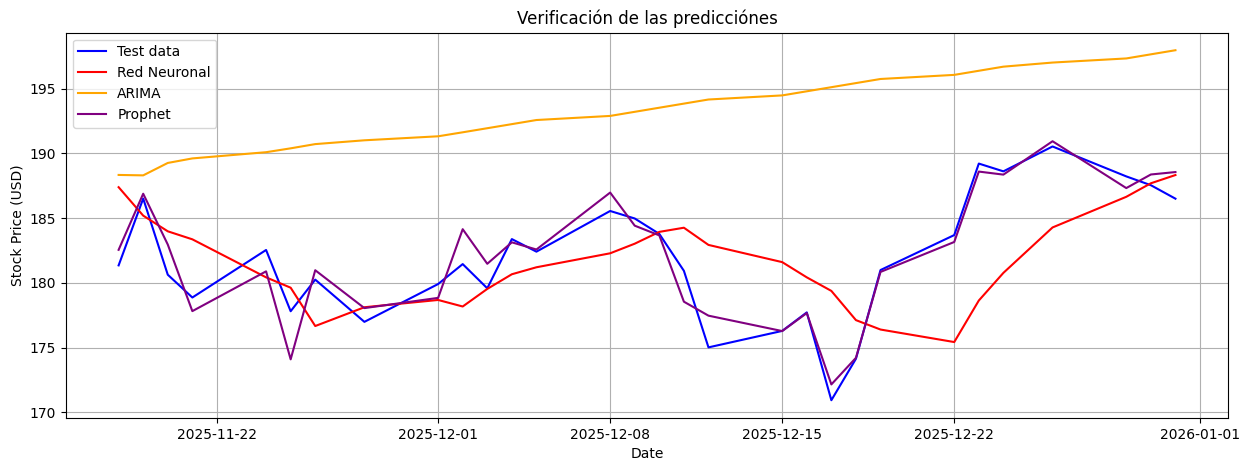

In [65]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

y_pred_n = y_pred + 0

rmse_rnn = root_mean_squared_error(y_true=y_true, y_pred=y_pred_n)
mae_rnn = mean_absolute_error(y_true=y_true, y_pred=y_pred_n)

rmse_arima = root_mean_squared_error(y_true=y_true, y_pred=preds)
mae_arima = mean_absolute_error(y_true=y_true, y_pred=preds)

rmse_prophet = root_mean_squared_error(y_true=y_true, y_pred=Prophet_predictions)
mae_prophet = mean_absolute_error(y_true=y_true, y_pred=Prophet_predictions)

print(f"Red Neuronal:\nMAE = {mae_rnn:.2f}, RMSE = {rmse_rnn:.2f}\n")
print(f"ARIMA:\nMAE = {mae_arima:.2f}, RMSE = {rmse_arima:.2f}\n")
print(f"Prophet:\nMAE = {mae_prophet:.2f}, RMSE = {rmse_prophet:.2f}\n")

test_data["Predictions"] = y_pred_n

x_plot = historical_data.index[training_len:]
plt.figure(figsize=(15,5))
# plt.plot(historical_data.index[:training_len], train_data["Close"], color = "g", label = "Test data")
plt.plot(x_plot, test_data["Close"], color = "b", label = "Test data")
plt.plot(x_plot, test_data["Predictions"], color = "r", label = "Red Neuronal")
plt.plot(x_plot, preds, color = "orange", label = "ARIMA")
plt.plot(x_plot, Prophet_predictions, color = "purple", label = "Prophet")


plt.grid()
plt.legend()
plt.title("Verificación de las predicciónes")
plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")
plt.plot()

## 7. Conclusiones
- **Peor modelo**: ARIMA
- **Modelo intermedio**: Red Neuronal
- **Mejor modelo** : Prophet

De acuerdo a las métricas usadas, el modelo que mejor se desempeñó fue el Prophet, además que es el más rápido en la fase de entrenamiento.

La ventaja que tiene Prophet es que es muy directo de usar, a comparación de la red neuronal, que al no tener un conocimiento tan profundo de estas, es más difícil de armar una red óptima. Similarmente, con la función AutoArima tardaba al rededor de 20 minutos entrenando con la periodicidad 252 (diaria), por lo que se optó por desactivar la regresión por estación.

